In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel
from models.rbf import RBFNet
from models.svm import LinearSVM
from utils.datasets import dataset_loader

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

In [2]:
def bold(string):
    return "\033[1m" + string + "\033[0m"

In [ ]:
# name = 'german_credit'
dropped_features = []#UCIDatasets().continuous_features[dataset]
# dataset = dataset_loader(name, dropped_features=dropped_features, n_bins=None)

In [ ]:
from data_loader.heloc import HelocData
seed = 42
data = HelocData(seed=seed)
dataset_name = "Heloc"
dataset = data

In [5]:
dataset.data

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance,RiskPerformance
0,55.0,144.0,4,84,20,3,0,83,2.0,3,5,23,1,43,0.0,0,0,33.0,74.0,8.0,1.0,1.0,69.0,0
1,61.0,58.0,15,41,2,4,4,100,15.0,0,8,7,0,67,0.0,0,0,0.0,74.0,0.0,2.0,1.0,0.0,0
2,67.0,66.0,5,24,9,0,0,100,15.0,7,8,9,4,44,0.0,4,4,53.0,66.0,4.0,2.0,1.0,86.0,0
3,66.0,169.0,1,73,28,1,1,93,76.0,6,6,30,3,57,0.0,5,4,72.0,83.0,6.0,4.0,3.0,91.0,0
4,81.0,333.0,27,132,12,0,0,100,15.0,7,8,12,0,25,0.0,1,1,51.0,89.0,3.0,1.0,0.0,80.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10454,73.0,131.0,5,57,21,0,0,95,80.0,6,6,21,5,19,7.0,0,0,26.0,74.0,5.0,2.0,0.0,100.0,1
10455,65.0,147.0,39,68,11,0,0,92,28.0,6,6,12,0,42,1.0,1,1,86.0,53.0,2.0,2.0,1.0,80.0,0
10456,74.0,129.0,6,64,18,1,1,100,15.0,6,8,18,1,33,3.0,4,4,6.0,74.0,5.0,2.0,0.0,56.0,0
10457,72.0,234.0,12,113,42,2,2,96,35.0,6,2,45,0,20,6.0,0,0,19.0,74.0,4.0,1.0,0.0,38.0,0


In [6]:
print("Testing HELOC dataset with complete fix...")
try:
    X_train, y_train, X_test, y_test, mean, std = dataset.get_split(normalise=False, shuffle=False, return_mean_std=True)
    prop1s = round(np.average(y_train)*100, 2)
    print("✅ HELOC dataset: SUCCESS")
    print(f"   X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
    print(f"   y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
    print(f"   Mean shape: {mean.shape}")  
    print(f"   Std shape: {std.shape}")
    print(bold("Proportion of 1s in Training Data:") + " {}%".format(prop1s))
    
    # Test PyTorch tensor conversion
    print("\nTesting PyTorch tensor conversion...")
    import torch
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)
    print("✅ PyTorch conversion: SUCCESS")
    print(f"   X_train_tensor shape: {X_train_tensor.shape}")
    print(f"   y_train_tensor shape: {y_train_tensor.shape}")
    
except Exception as e:
    print(f"❌ HELOC dataset: FAILED - {e}")
    import traceback
    traceback.print_exc()

Testing HELOC dataset with complete fix...
✅ HELOC dataset: SUCCESS
   X_train shape: (7896, 23), dtype: float64
   y_train shape: (7896,), dtype: float64
   Mean shape: (23,)
   Std shape: (23,)
Proportion of 1s in Training Data: 47.19%

Testing PyTorch tensor conversion...
✅ PyTorch conversion: SUCCESS
   X_train_tensor shape: torch.Size([7896, 23])
   y_train_tensor shape: torch.Size([7896, 1])


In [ ]:
X = pd.DataFrame(X_train)
X.columns = dataset.features[:-1]
X_train = pd.DataFrame(X_train)
X_train.columns = dataset.features[:-1]
X_test = pd.DataFrame(X_test)
X_test.columns = dataset.features[:-1]
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)
# print(bold("Dataset:") + " {}\n".format(name.replace('_', ' ').title()))


Dataset: Heloc



,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,MaxDelqEver,NumTotalTrades,NumTradesOpeninLast12M,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,55.0,144.0,4.0,84.0,20.0,3.0,0.0,83.0,2.0,3.0,5.0,23.0,1.0,43.0,0.0,0.0,0.0,33.0,74.0,8.0,1.0,1.0,69.0
1,61.0,58.0,15.0,41.0,2.0,4.0,4.0,100.0,15.0,0.0,8.0,7.0,0.0,67.0,0.0,0.0,0.0,0.0,74.0,0.0,2.0,1.0,0.0
2,67.0,66.0,5.0,24.0,9.0,0.0,0.0,100.0,15.0,7.0,8.0,9.0,4.0,44.0,0.0,4.0,4.0,53.0,66.0,4.0,2.0,1.0,86.0
3,66.0,169.0,1.0,73.0,28.0,1.0,1.0,93.0,76.0,6.0,6.0,30.0,3.0,57.0,0.0,5.0,4.0,72.0,83.0,6.0,4.0,3.0,91.0
4,81.0,333.0,27.0,132.0,12.0,0.0,0.0,100.0,15.0,7.0,8.0,12.0,0.0,25.0,0.0,1.0,1.0,51.0,89.0,3.0,1.0,0.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7891,68.0,182.0,19.0,94.0,19.0,0.0,0.0,90.0,2.0,4.0,6.0,20.0,0.0,40.0,0.0,3.0,3.0,5.0,48.0,3.0,3.0,0.0,55.0
7892,57.0,107.0,3.0,53.0,25.0,1.0,1.0,96.0,15.0,6.0,3.0,26.0,4.0,54.0,0.0,7.0,7.0,89.0,36.0,5.0,3.0,2.0,82.0
7893,65.0,94.0,6.0,43.0,31.0,2.0,1.0,91.0,38.0,6.0,5.0,36.0,5.0,42.0,0.0,0.0,0.0,18.0,88.0,5.0,3.0,0.0,50.0
7894,75.0,293.0,9.0,143.0,9.0,0.0,0.0,89.0,11.0,4.0,6.0,9.0,2.0,22.0,0.0,0.0,0.0,59.0,78.0,3.0,1.0,1.0,57.0


In [8]:
# B_name = 'dnn'  # 'lr' or 'dnn' or 'xgb'
# if B_name == 'dnn':
#     from models.models_global_ce import dnn_normalisers as normalisers
# elif B_name == 'lr':
#     from models.models_global_ce import lr_normalisers as normalisers
# else:  # no xgb normalisation
#     normalisers = {name: False}
# normalise = [mean, std] if normalisers[name] else None

In [9]:
# import pickle
# with open('data/models_global_ce/{}_{}.pkl'.format(name, B_name), 'rb') as f:
#     B = pickle.load(f)

In [10]:
# print(bold("Dataset:") + " {}".format(name.replace('_', ' ').title()))
# print(bold("Model:") + " {}\n".format(B_name.replace('_', ' ').upper()))
# performance(B, x_train, x_test, y_train, y_test, normalise=normalise)

In [11]:
target_name = 'RiskPerformance'

In [ ]:


X_train, X_test, y_train, y_test = data.get_train_test()

X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values

In [13]:
seed = 42

np.random.seed(seed)  # for reproducibility
torch.manual_seed(seed)
# std = X_train.std()
# mean = X_train.mean()

# X_train = (X_train - mean) / std
# X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Initialize the model, loss function, and optimizer
# model = BlackBoxModel(input_dim=X_train.shape[1])
# model = RBFNet(input_dim=X_train.shape[1], hidden_dim=X_train.shape[1])
model = LinearSVM(input_dim=X_train.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    # Convert outputs to binary using 0.5 as threshold
    y_pred_tensor = (test_outputs > 0.5).float()
    correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
    accuracy = correct_predictions / y_test_tensor.shape[0]

accuracy.item()

0.6964626908302307

In [14]:
sample_num = 100
# indice = (X_test.sample(sample_num)).index

# Fixing the indice for test purpose
indice = [1825, 1735,  678,  351, 1791,  610,   70, 1124,   56,  900,  555,
             746, 1704,  462, 1873,  289,  593,  824,  530, 1424, 1063,  486,
             892,  554,  777, 1234, 1216,  374,  439, 1271,  651,  211,  886,
            1329, 1005, 1102, 1052,  111,  344,  305, 1376,  931, 1041, 1010,
            1640,  316,  432,  353,  426,  394, 1360, 1131,   99,  859, 1270,
             237, 1465,  710, 1653,  538,  382, 1830, 1632, 1314, 1781, 1494,
            1831, 1721,   69, 1788, 1546, 1753, 1931,  429, 1436, 1755,  251,
             756,  855,  128,  637,  864, 1809, 1402,  361, 1578, 1091, 1810,
            1615, 1138,  247,  845, 1628, 1239,  196, 1033,  584,  548,  722,
            1840]

X_test = pd.DataFrame(X_test, columns=X.columns)
df_explain = X_test.loc[indice]

y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))
y_test = pd.Series(y_test.reshape(-1))
y_true = y_test.loc[indice]

y = model(torch.FloatTensor(df_explain.values))

In [15]:
# df_compare = pd.DataFrame({
#     "y_true": y_true.values,
#     "y_pred": y.detach().numpy().squeeze()  
# })

# df_compare.head(50)

## GLOBE_CE

In [16]:
from explainers.globe_ce import GLOBE_CE

In [17]:
normalise = None

# AReS initiated to determine bin widths for costs
from explainers.ares import AReS
ares = AReS(model=model, dataset=dataset, X=dataset.data.drop(target_name,axis=1), n_bins=10, normalise=normalise)  # 1MB
bin_widths = ares.bin_widths

In [18]:
# example of ordinal features usage
ordinal_features = ['Present-Employment'] if name == 'german_credit' else []
# initialise GLOBE_CE
globe_ce = GLOBE_CE(model=model, dataset=dataset, X=df_explain, affected_subgroup=None,
                    dropped_features=dropped_features, ordinal_features=ordinal_features, delta_init='zeros',
                    normalise=normalise, bin_widths=bin_widths, monotonicity=None, p=1)

100%|██████████| 100/100 [00:00<00:00, 6839.36it/s]


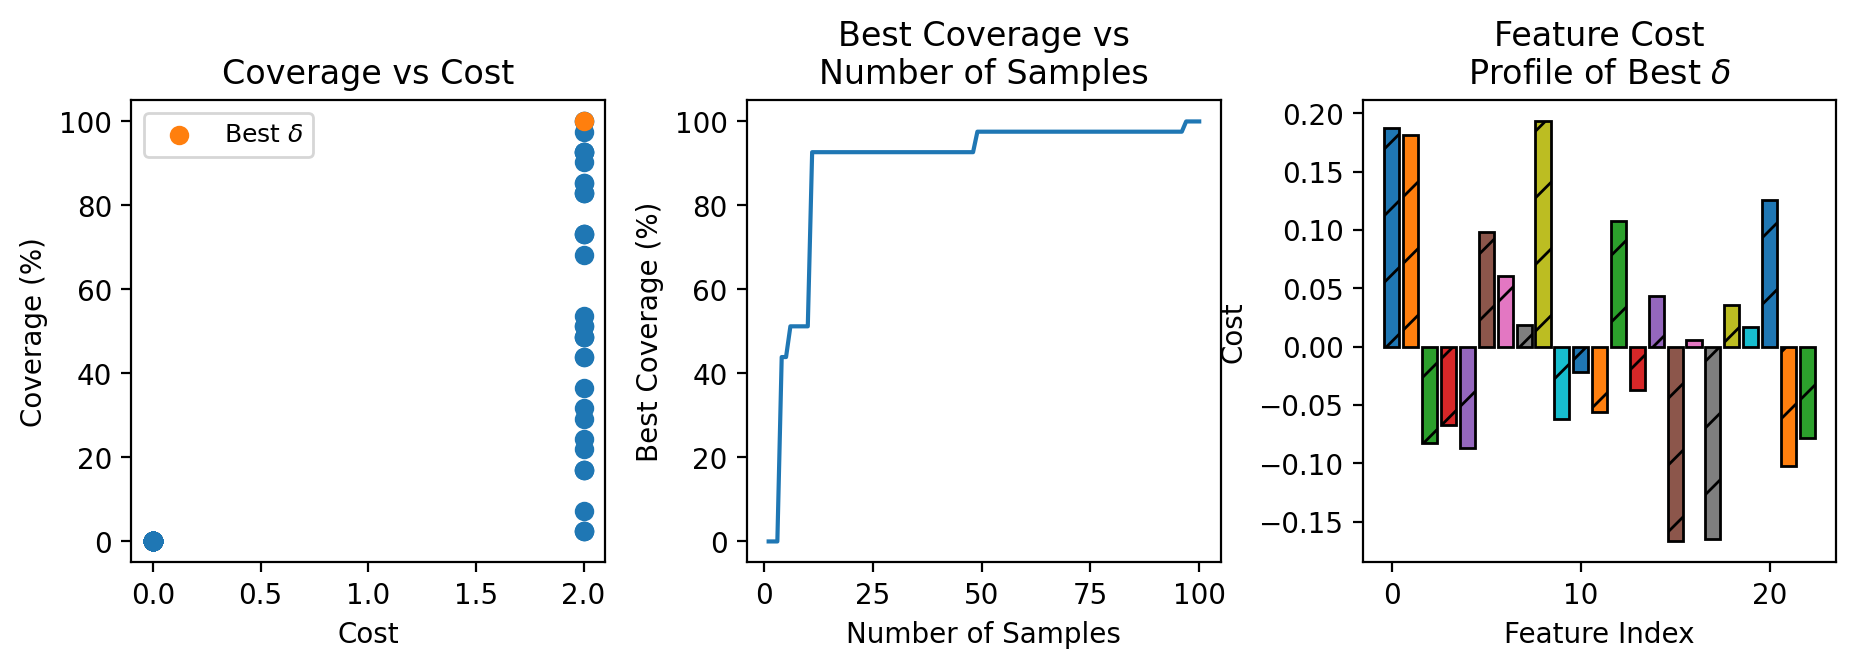

In [19]:
globe_ce.sample(n_sample=sample_num, magnitude=2, sparsity_power=1,  # magnitude is the fixed cost sampled at
                idxs=None, n_features=df_explain.shape[1], disable_tqdm=False,  # 2 random features chosen at each sample, no sparsity smoothing (p=1)
                plot=True, seed=0, scheme='random', dropped_features=dropped_features)
delta = globe_ce.best_delta  # pick best delta
globe_ce.select_n_deltas(n_div=3)

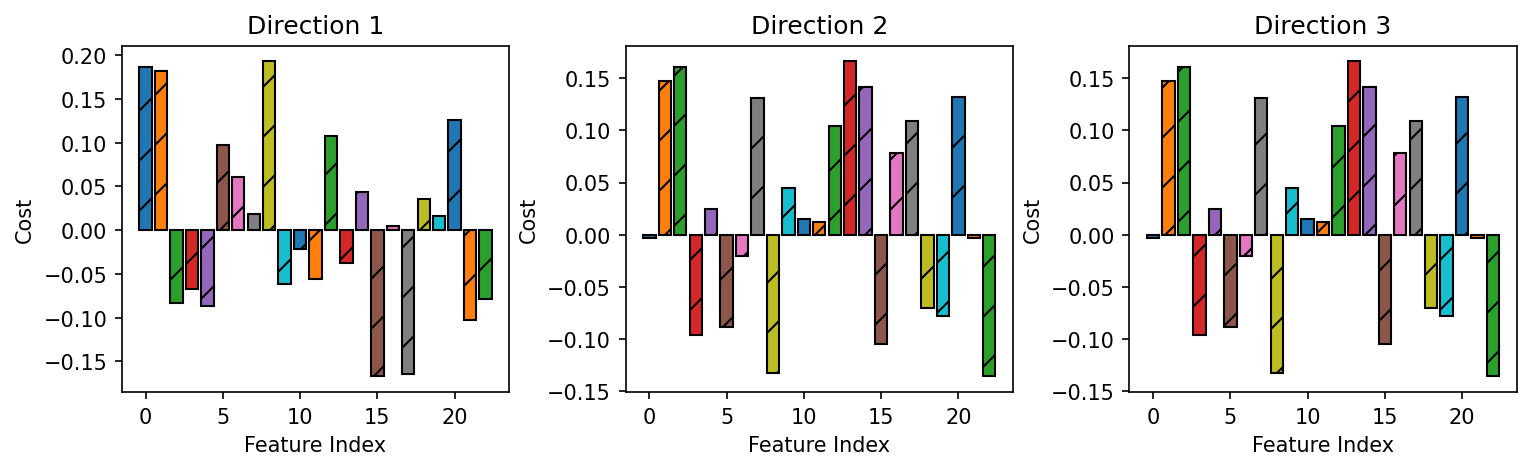

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=globe_ce.deltas_div.shape[0], dpi=150)
fig.set_figwidth(12)
fig.set_figheight(3)
plt.subplots_adjust(wspace=0.3)
for i in range(globe_ce.deltas_div.shape[0]):
    delta_cost = globe_ce.deltas_div[i] * globe_ce.feature_costs_vector
    cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    j, k = 0, 0
    for feature in globe_ce.features_tree:
        if not globe_ce.features_tree[feature]:
            ax[i].bar(range(j, j+1), delta_cost[j], hatch='/',
                        linewidth=1, edgecolor='black', color=cycle[k%len(cycle)])
            j += 1
            k += 1
        else:
            feature_values = globe_ce.features_tree[feature]
            n_f = len(feature_values)
            ax[2].bar(range(j, j+n_f), delta_cost[j:j+n_f], color=cycle[k%len(cycle)])
            j += n_f
            k += 1
    ax[i].set_title(f'Direction {i+1}')
    ax[i].set_xlabel('Feature Index')
    ax[i].set_ylabel('Cost')
plt.show()

In [21]:
n_div = globe_ce.deltas_div.shape[0]
min_costs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
min_costs_idxs = np.zeros((n_div, globe_ce.x_aff.shape[0]))
for i in range(n_div):  # Algorithm 1, Line 2
    cor_s, cos_s, k_s = globe_ce.scale(globe_ce.deltas_div[i], disable_tqdm=False, vector=True)  # Algorithm 1, Line 3
    min_costs[i], min_costs_idxs[i] = globe_ce.min_scalar_costs(cos_s, return_idxs=True, inf=True)  # Implicitly computes Algorithm 1, Lines 4-6, returning minimum costs per input and their indices in the k vector
    max_scalar_idxs = globe_ce.cluster_by_costs(cos_s, n_bins=5)
min_costs = min_costs.min(axis=0)

100%|██████████| 1000/1000 [00:00<00:00, 14366.51it/s]


Unable to find recourse for 0/41 inputs


100%|██████████| 1000/1000 [00:00<00:00, 14331.02it/s]


Unable to find recourse for 0/41 inputs


100%|██████████| 1000/1000 [00:00<00:00, 14485.85it/s]

Unable to find recourse for 0/41 inputs


In [22]:
ces = globe_ce.round_categorical(globe_ce.x_aff+globe_ce.best_delta) if globe_ce.n_categorical else globe_ce.x_aff+globe_ce.best_delta
counterfactual_X_global_ce = pd.DataFrame(ces, columns=X_test.columns)
counterfactual_y_global_ce = model.predict(counterfactual_X_global_ce.values)

In [23]:
print('Coverage (Globe CE):', counterfactual_y_global_ce.sum()/len(counterfactual_y_global_ce))

Coverage (Globe CE): 1.0


In [24]:
factual_X = pd.DataFrame(globe_ce.x_aff, columns=df_explain.columns)
factual_y = model.predict(factual_X.values)

In [25]:
# y_target = torch.ones(factual_X.shape[0])

In [26]:
costs_vector = globe_ce.feature_costs_vector

## AReS

In [27]:
# AReS initiated to determine bin widths for costs
from explainers.ares import AReS
ares = AReS(model=model, dataset=dataset, X=factual_X, n_bins=10, normalise=normalise)  # 1MB

Computing Candidate Sets of Conjunctions of Predicates SD and RL
Processing 42 combinations | Sampling itemset size 654
SD and RL Computed with Lengths 245 and 245
Computing Ground Set of Triples V
Reducing RL
RL Reduced from Size 245 to 50


100%|██████████| 245/245 [00:00<00:00, 4115.65it/s]


Ground Set Computed with Length 11182


4999it [00:03, 1448.60it/s]


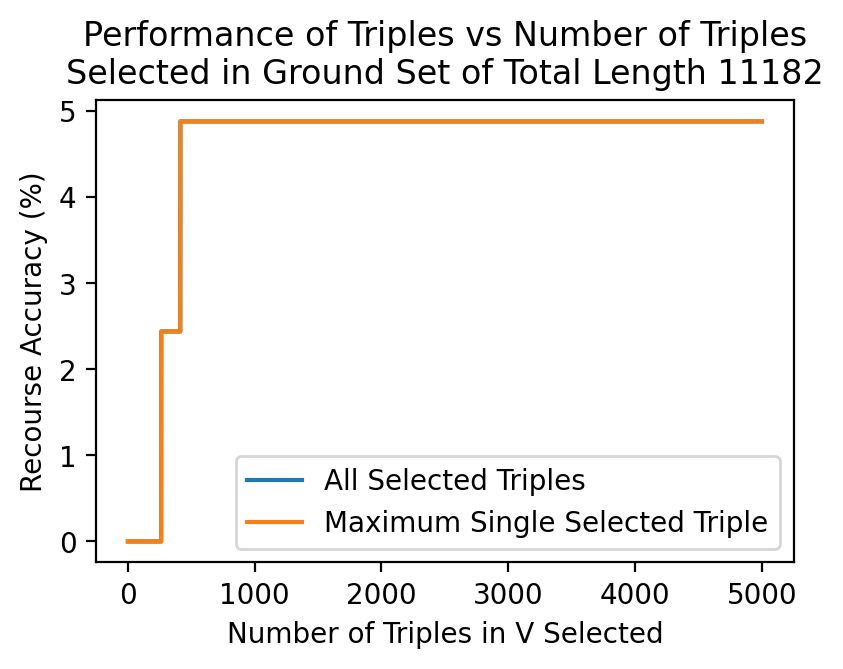

Candidate Set Filtered with Length: 5000
Initialising Copy of Ground Set
While there exists a delete/update operation, loop:
Checking Delete
Checking Add


100%|██████████| 4999/4999 [00:00<00:00, 30758.85it/s]


Checking Exchange


100%|██████████| 4999/4999 [00:00<00:00, 70333.72it/s]
0it [00:00, ?it/s]


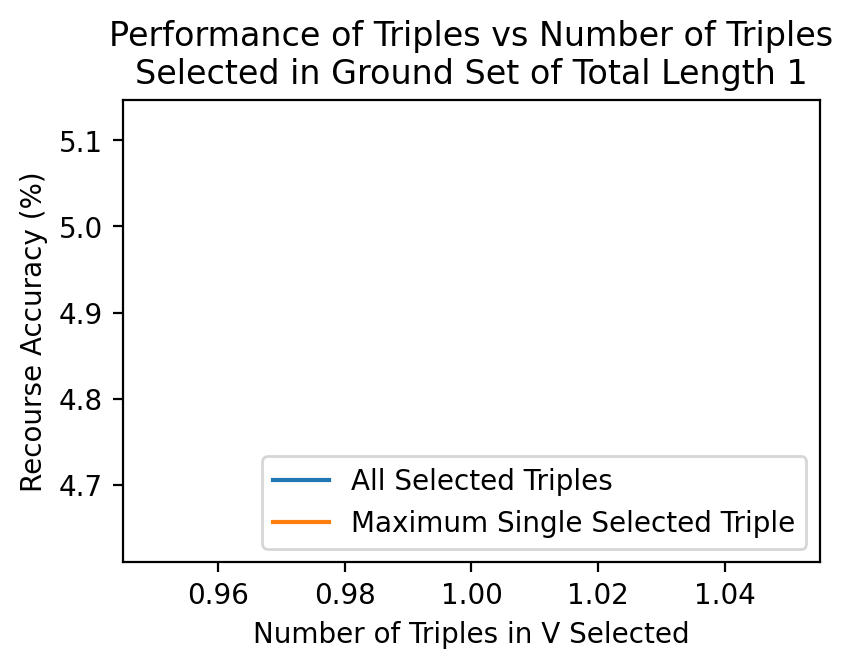

In [28]:
ares.generate_itemsets(apriori_threshold=0.2, max_width=None, # defaults to e2-1
                       affected_subgroup=None, save_copy=False)
# Note: progress bar initial time estimate about 10 times too large
ares.generate_groundset(max_width=None, RL_reduction=True,
                        then_generation=None, save_copy=False)
lams = [1, 0]  # can play around with these lambda values
ares.evaluate_groundset(lams=lams, r=5000, save_mode=1,
                        disable_tqdm=False, plot_accuracy=True)
ares.select_groundset(s=5000)
ares.optimise_groundset(lams=lams, factor=1, print_updates=False,
                        print_terms=False)

In [29]:
counterfactual_X_ares = pd.DataFrame(ares.R.cfx_matrix[0], columns=X_test.columns)
counterfactual_y_ares = model.predict(counterfactual_X_ares.values)

In [30]:
print('Coverage (AReS):', counterfactual_y_ares.sum()/len(counterfactual_y_ares))

Coverage (AReS): 0.04878048780487805


## Diverse Counterfactual Explanation (DiCE)

In [31]:
backend = 'PYT'  # needs pytorch installed

In [32]:
import dice_ml

m = dice_ml.Model(model=model, backend='PYT')

factual_X_ext = factual_X.copy()
factual_X_ext[target_name] = factual_y

dice_features = factual_X.columns.to_list()

d = dice_ml.Data(dataframe=factual_X_ext, continuous_features=dice_features, outcome_name = target_name)

dice_explainer = dice_ml.Dice(d, m, method="gradient")

In [33]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"dice_results_{model.name}_heloc.pkl"), 'rb') as file:
#     dice_results = pickle.load(file)

In [34]:
dice_results = dice_explainer.generate_counterfactuals(query_instances=factual_X, features_to_vary=dice_features, desired_class="opposite", total_CFs=1)

  0%|          | 0/41 [00:00<?, ?it/s]WARNING:root: MAD for feature NumTrades60Ever2DerogPubRec is 0, so replacing it with 1.0 to avoid error.
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.828042190896938e-09' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001916027859954536' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\e

Diverse Counterfactuals found! total time taken: 00 min 00 sec


d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6791985134942627' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3808359007699585' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value

Diverse Counterfactuals found! total time taken: 00 min 00 sec


d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.828042190896938e-09' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4638754327433014' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. V

...

Diverse Counterfactuals found! total time taken: 00 min 00 sec


d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.828042190896938e-09' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.525250260479226e-09' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of panda

Diverse Counterfactuals found! total time taken: 00 min 01 sec


d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-9.828042190896938e-09' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.00000001' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  final_cfs_sparse.at[cf_ix, feature] += np.sign(diff)*change
d:\Anaconda\envs\DCE\Lib\site-packages\dice_ml\explainer_interfaces\explainer_base.py:596: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1

Diverse Counterfactuals found! total time taken: 00 min 00 sec


In [35]:
# Iterate through each result and append to the DataFrame
dice_df_list = []
for cf in dice_results.cf_examples_list:
    # Convert to DataFrame and append
    cf_df = cf.final_cfs_df
    dice_df_list.append(cf_df)

counterfactual_X_dice = pd.concat(dice_df_list).reset_index(drop=True).drop(target_name, axis=1)

In [36]:
counterfactual_y_dice = model.predict(counterfactual_X_dice.values)

In [37]:
print('Coverage (DiCE):', counterfactual_y_dice.sum()/len(counterfactual_y_dice))

Coverage (DiCE): 1.0


In [38]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"dice_results_{model.name}_heloc.pkl"), "wb") as file:
#     pickle.dump(dice_results, file)

## Distributional Counterfactual Explanation (DCE)

In [ ]:
from explainers.DCEgradient import DCEExplainerGradient
from explainers.model import Model

# Wrap the model for DCE compatibility
model_wrapped = Model(model=model, backend="pytorch", data=data)

# Initialize the explainer
explainer = DCEExplainerGradient(model_wrapped, data)

# Set df_explain in data object for compatibility
data.df_explain = factual_X
data.sample_num = len(factual_X)

print("✅ DCE Gradient explainer initialized!")

✅ DCE Gradient explainer initialized!


In [40]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"explainer_{model.name}_heloc.pkl"), 'rb') as file:
#     explainer = pickle.load(file)

In [ ]:
# Run DCE explanation using gradient descent
df_cf_gradient = explainer.explain(
    df_factual=factual_X,
    X_init=True,  # Use perturbed initial data
    n_proj=10,    # N = 10 as in original
    delta=0.1,    # Increase delta for standardized data (was 1e-5)
    U_1=0.5,      # Increase U_1 for standardized data scale (was 0.01) 
    U_2=1.0,      # Increase U_2 for standardized data scale (was 0.2)
    l=0.7,        # l parameter unchanged
    r=0.85,       # r parameter unchanged
    max_iter=100, # max_iter as in original
    callback="off",  # Disable callback for baseline compatibility
    save_results=True,  # Save results
    dataset_name=dataset_name,
    model_name='SVM',
    seed=42
)

print(f"✅ DCE Gradient explanation completed!")
print(f"🎯 Best Q: {explainer.best_Q:.6f}")
print(f"📊 Final Q: {explainer.final_Q:.6f}")

In [42]:
# import os 
# import pickle 
# dump_data_path = './data/baseline/'
# with open(os.path.join(dump_data_path, f"explainer_{model.name}_heloc.pkl"), "wb") as file:
#     pickle.dump(explainer, file)

In [43]:
X_train = pd.DataFrame(X_train, columns=X.columns)

In [ ]:
# Process DCE results from gradient.py
counterfactual_X_dce = df_cf_gradient.copy()

# Apply data type recovery (same as original)
dtype_dict = X_train.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X_dce.columns:
        if v[:3] == 'int':
            counterfactual_X_dce[k] = counterfactual_X_dce[k].round().astype(v)
        else:
            counterfactual_X_dce[k] = counterfactual_X_dce[k].astype(v)

# Get counterfactual predictions
counterfactual_y_prob_dce = pd.DataFrame(
    model.predict(counterfactual_X_dce.values),
    columns=[target_name], 
    index=counterfactual_X_dce.index
)
counterfactual_y_dce = (counterfactual_y_prob_dce.values > 0.5).astype(int).reshape(-1)
print('Coverage (DCE):', counterfactual_y_dce.sum()/len(counterfactual_y_dce))

Coverage (DCE): 1.0


In [45]:
print('Coverage (DCE):', counterfactual_y_dce.sum()/len(counterfactual_y_dce))

Coverage (DCE): 1.0


## Distance Evaluation

In [46]:
from explainers.distances import SlicedWassersteinDivergence, WassersteinDivergence
from scipy.stats import gaussian_kde, entropy
from numpy.linalg import LinAlgError
import numpy as np
from scipy.spatial.distance import pdist, cdist, squareform

def compute_distance(X_s, X_t):
    if type(X_s) == pd.DataFrame:
        X_s = torch.FloatTensor(X_s.values)
    if type(X_t) == pd.DataFrame:
        X_t = torch.FloatTensor(X_t.values)

    if type(X_s) == np.ndarray:
        X_s = torch.FloatTensor(X_s)
    if type(X_t) == np.ndarray:
        X_t = torch.FloatTensor(X_t)

    if X_s.ndim == 1:
        wd = WassersteinDivergence()
        distance, _ = wd.distance(X_s, X_t, delta=0.1)
    else:
        swd = SlicedWassersteinDivergence(
                dim=X_s.shape[1], n_proj=5000
        )
        distance, _ = swd.distance(X_s, X_t, delta=0.1)
    return distance.item()


def compute_kl_divergence(X_s, X_t):
    kl_divergences = []
    for i in range(X_s.shape[1]):  # Iterate over columns (features)
        try:
            # Estimate probability distributions using KDE
            kde_s = gaussian_kde(X_s[:, i])
            kde_t = gaussian_kde(X_t[:, i])

            # Evaluate the densities on a linear space of the same range
            x_min = min(X_s[:, i].min(), X_t[:, i].min())
            x_max = max(X_s[:, i].max(), X_t[:, i].max())
            x = np.linspace(x_min, x_max, 1000)

            # Compute the KL divergence (entropy)
            kl_div = entropy(kde_s(x), kde_t(x))
        except LinAlgError:
            # Catch the singular matrix error and set the divergence to infinity
            kl_div = np.inf

        kl_divergences.append(kl_div)

    # Aggregate the KL divergences
    total_kl_divergence = np.sum(kl_divergences)  # Or use np.mean for average
    return total_kl_divergence

def gaussian_kernel(x, y, sigma=1.0):
    """Compute the Gaussian kernel between x and y"""
    return np.exp(-np.linalg.norm(x - y) ** 2 / (2 * sigma ** 2))

def mmd(X_s, X_t, kernel=gaussian_kernel):
    """Compute the Maximum Mean Discrepancy (MMD) between two samples X_s and X_t"""
    n = X_s.shape[0]
    m = X_t.shape[0]

    # Calculate the kernel values between all points in the first sample
    XX = np.sum([kernel(X_s[i], X_s[j]) for i in range(n) for j in range(n)])
    
    # Calculate the kernel values between all points in the second sample
    YY = np.sum([kernel(X_t[i], X_t[j]) for i in range(m) for j in range(m)])
    
    # Calculate the kernel values between all points across the two samples
    XY = np.sum([kernel(X_s[i], X_t[j]) for i in range(n) for j in range(m)])

    return XX / (n ** 2) + YY / (m ** 2) - 2 * XY / (n * m)

In [47]:
cov_ares = counterfactual_y_ares.sum()/len(counterfactual_y_ares)
cov_global_ce = counterfactual_y_global_ce.sum()/len(counterfactual_y_global_ce)
cov_dice = counterfactual_y_dice.sum()/len(counterfactual_y_dice)
cov_dce = counterfactual_y_dce.sum()/len(counterfactual_y_dce)

In [48]:
print('Coverage (AReS):', cov_ares)
print('Coverage (Globe CE):', cov_global_ce)
print('Coverage (DiCE):', cov_dice)
print('Coverage (DCE):', cov_dce)

Coverage (AReS): 0.04878048780487805
Coverage (Globe CE): 1.0
Coverage (DiCE): 1.0
Coverage (DCE): 1.0


In [49]:
ot_dist_ares = compute_distance(X_s=counterfactual_X_ares, X_t=factual_X)
ot_dist_global_ce = compute_distance(X_s=counterfactual_X_global_ce, X_t=factual_X)
ot_dist_dce = compute_distance(X_s=counterfactual_X_dce, X_t=factual_X)
ot_dist_dice = compute_distance(X_s=counterfactual_X_dice.dropna(), X_t=factual_X)


print('X Distance (AReS):', ot_dist_ares)
print('X Distance (Globe CE):', ot_dist_global_ce)
print('X Distance (DiCE):', ot_dist_dice)
print('X Distance (DCE):', ot_dist_dce)

X Distance (AReS): 0.000413073314120993
X Distance (Globe CE): 13.746030807495117
X Distance (DiCE): 0.6510329842567444
X Distance (DCE): 3281.75341796875


In [50]:
print('X MMD (AReS):', mmd(X_s=counterfactual_X_ares.values, X_t=factual_X.values))
print('X MMD (Globe CE):', mmd(X_s=counterfactual_X_global_ce.values, X_t=factual_X.values))
print('X MMD (DiCE):', mmd(X_s=counterfactual_X_dice.dropna().values, X_t=factual_X.values))
print('X MMD (DCE):', mmd(X_s=counterfactual_X_dce.values, X_t=factual_X.values))

X MMD (AReS): 0.0002539065776269167
X MMD (Globe CE): 0.049585506430352214
X MMD (DiCE): 0.13889839831903433
X MMD (DCE): 0.04918299711761513


In [51]:
print('X KL-Divergence (AReS):', 
      compute_kl_divergence(X_s=counterfactual_X_ares.values, X_t=factual_X.values))
print('X KL-Divergence (Globe CE):', 
      compute_kl_divergence(X_s=counterfactual_X_global_ce.values, X_t=factual_X.values))
print('X KL-Divergence (DiCE):', 
      compute_kl_divergence(X_s=counterfactual_X_dice.dropna().values, X_t=factual_X.values))
print('X KL-Divergence (DCE):', 
      compute_kl_divergence(X_s=counterfactual_X_dce.values, X_t=factual_X.values))

X KL-Divergence (AReS): 0.0004872793541478163
X KL-Divergence (Globe CE): 451.74842843352155
X KL-Divergence (DiCE): inf
X KL-Divergence (DCE): inf


In [52]:
ares_diff_pct = []
globe_ce_diff_pct = []
dice_diff_pct = []
dce_diff_pct = []
for column in df_explain.columns:
    ares_pct = (counterfactual_X_ares[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    globe_ce_pct = (counterfactual_X_global_ce[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    dice_pct = (counterfactual_X_dice[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())
    dce_pct = (counterfactual_X_dce[column] - factual_X[column]).abs().sum() / (1e-7 + factual_X[column].abs().sum())

    ares_diff_pct.append({column: ares_pct})
    globe_ce_diff_pct.append({column: globe_ce_pct})
    dice_diff_pct.append({column: dice_pct})
    dce_diff_pct.append({column: dce_pct})

## Cost Evaluation

In [53]:
def compute_cost(delta, costs_vector):
    return np.linalg.norm(delta @ np.diag(costs_vector)) 

from scipy.stats import ks_2samp

def compute_quantile_shift(counterfactul_X, factual_X):
    columns = counterfactul_X.columns

    ks_statistic_list = []
    p_value_list = []

    for column in columns:
        ks_statistic, p_value = ks_2samp(counterfactul_X[column].values, factual_X[column].values)

    ks_statistic_list.append(ks_statistic)
    p_value_list.append(p_value)

    return np.mean(ks_statistic_list)

def compute_percentile_difference(counterfactual_X, factual_X, percentiles):
    columns = counterfactual_X.columns
    diff_list = []
    for percentile in percentiles:
        for column in columns:
            perc_cf = np.percentile(counterfactual_X[column].values, percentile)
            perc_f = np.percentile(factual_X[column].values, percentile)

            diff_list.append(abs(perc_cf - perc_f)/abs(perc_f) * 100)

    return np.mean(diff_list)


In [54]:
ares_delta = (counterfactual_X_ares - factual_X).values
globe_ce_delta = (counterfactual_X_global_ce - factual_X).values
dce_delta = (counterfactual_X_dce - factual_X).values
dice_delta = (counterfactual_X_dice - factual_X).values
dice_delta = (counterfactual_X_dice.dropna() - factual_X.loc[counterfactual_X_dice.dropna().index]).values

In [55]:
print('Cost (AReS):', compute_cost(ares_delta, costs_vector))
print('Cost (Globe CE):', compute_cost(globe_ce_delta, costs_vector))
print('Cost (DiCE):', compute_cost(dice_delta, costs_vector))
print('Cost (DCE):', compute_cost(dce_delta, costs_vector))

Cost (AReS): 0.10051143322710301
Cost (Globe CE): 3.19677683851836
Cost (DiCE): 15.01564682966605
Cost (DCE): 149.7731296854735


In [56]:
percentiles = np.arange(0, 15, 0.1)
print('Percentile Shift Cost (AReS):', compute_percentile_difference(counterfactual_X_ares, factual_X, percentiles))
print('Percentile Shift Cost (Globe CE):', compute_percentile_difference(counterfactual_X_global_ce, factual_X, percentiles))
print('Percentile Shift Cost (DiCE):', compute_percentile_difference(counterfactual_X_dice.dropna(), factual_X, percentiles))
print('Percentile Shift Cost (DCE):', compute_percentile_difference(counterfactual_X_dce, factual_X, percentiles))

Percentile Shift Cost (AReS): 0.0
Percentile Shift Cost (Globe CE): 171.5218353305879
Percentile Shift Cost (DiCE): 115.43402954126589
Percentile Shift Cost (DCE): 1496.3496201399732


In [57]:
percentiles = np.arange(15, 30, 1)
print('Percentile Shift Cost (AReS):', compute_percentile_difference(counterfactual_X_ares, factual_X, percentiles))
print('Percentile Shift Cost (Globe CE):', compute_percentile_difference(counterfactual_X_global_ce, factual_X, percentiles))
print('Percentile Shift Cost (DiCE):', compute_percentile_difference(counterfactual_X_dice.dropna(), factual_X, percentiles))
print('Percentile Shift Cost (DCE):', compute_percentile_difference(counterfactual_X_dce, factual_X, percentiles))

Percentile Shift Cost (AReS): 0.0
Percentile Shift Cost (Globe CE): 900.4990039455229
Percentile Shift Cost (DiCE): 119.86750694630565
Percentile Shift Cost (DCE): 13351.654125312654


In [58]:
percentiles = np.arange(30, 70, 1)
print('Percentile Shift Cost (AReS):', compute_percentile_difference(counterfactual_X_ares, factual_X, percentiles))
print('Percentile Shift Cost (Globe CE):', compute_percentile_difference(counterfactual_X_global_ce, factual_X, percentiles))
print('Percentile Shift Cost (DiCE):', compute_percentile_difference(counterfactual_X_dice.dropna(), factual_X, percentiles))
print('Percentile Shift Cost (DCE):', compute_percentile_difference(counterfactual_X_dce, factual_X, percentiles))

Percentile Shift Cost (AReS): 1.647547311525438
Percentile Shift Cost (Globe CE): 1054.7013414510698
Percentile Shift Cost (DiCE): 132.56455578349954
Percentile Shift Cost (DCE): 29390.634624678285


In [59]:
percentiles = np.arange(70, 85, 1)
print('Percentile Shift Cost (AReS):', compute_percentile_difference(counterfactual_X_ares, factual_X, percentiles))
print('Percentile Shift Cost (Globe CE):', compute_percentile_difference(counterfactual_X_global_ce, factual_X, percentiles))
print('Percentile Shift Cost (DiCE):', compute_percentile_difference(counterfactual_X_dice.dropna(), factual_X, percentiles))
print('Percentile Shift Cost (DCE):', compute_percentile_difference(counterfactual_X_dce, factual_X, percentiles))

Percentile Shift Cost (AReS): 0.0
Percentile Shift Cost (Globe CE): 961.8301955023237
Percentile Shift Cost (DiCE): 60.03672634500185
Percentile Shift Cost (DCE): 15262.249787505014


In [60]:
percentiles = np.arange(85, 100, 1)
print('Percentile Shift Cost (AReS):', compute_percentile_difference(counterfactual_X_ares, factual_X, percentiles))
print('Percentile Shift Cost (Globe CE):', compute_percentile_difference(counterfactual_X_global_ce, factual_X, percentiles))
print('Percentile Shift Cost (DiCE):', compute_percentile_difference(counterfactual_X_dice.dropna(), factual_X, percentiles))
print('Percentile Shift Cost (DCE):', compute_percentile_difference(counterfactual_X_dce, factual_X, percentiles))

Percentile Shift Cost (AReS): 0.0
Percentile Shift Cost (Globe CE): 249.2388455195991
Percentile Shift Cost (DiCE): 76.38314172115365
Percentile Shift Cost (DCE): 7528.0491927959


## Diversity

In [61]:
def compute_average_pairwise_distance(counterfactual_X):
    n = len(counterfactual_X)
    total_distance = 0
    count = 0

    for i in range(n):
        for j in range(i+1, n):
            dist = np.linalg.norm(counterfactual_X.iloc[i] - counterfactual_X.iloc[j])
            total_distance += dist
            count += 1

    if count > 0:
        average_distance = total_distance / count
    else:
        average_distance = 0

    return average_distance

In [62]:
print('Diversity (Factual)', compute_average_pairwise_distance(factual_X))

Diversity (Factual) 6.7456093909002846


In [63]:
print('Diversity (AReS):', compute_average_pairwise_distance(counterfactual_X_ares))
print('Diversity (Globe CE):', compute_average_pairwise_distance(counterfactual_X_global_ce))
print('Diversity (DiCE):', compute_average_pairwise_distance(counterfactual_X_dice.dropna()))
print('Diversity (DCE):', compute_average_pairwise_distance(counterfactual_X_dce))

Diversity (AReS): 6.751656034308462
Diversity (Globe CE): 6.7456093909002846
Diversity (DiCE): 2.3544939989308062
Diversity (DCE): 137.11818222212443


In [64]:
print('Effective Diversity (AReS):', compute_average_pairwise_distance(counterfactual_X_ares)/ot_dist_ares * cov_ares)
print('Effective Diversity (Globe CE):', compute_average_pairwise_distance(counterfactual_X_global_ce)/ot_dist_global_ce * cov_global_ce)
print('Effective Diversity (DiCE):', compute_average_pairwise_distance(counterfactual_X_dice)/ot_dist_dice * cov_dice)
print('Effective Diversity (DCE):', compute_average_pairwise_distance(counterfactual_X_dce)/ot_dist_dce * cov_dce)


Effective Diversity (AReS): 797.3138510415753
Effective Diversity (Globe CE): 0.4907314326126925
Effective Diversity (DiCE): 3.616551013338945
Effective Diversity (DCE): 0.04178198808946289
